# 🌾 India Crop Yield Prediction — Notebook 7: Prediction Pipeline

**Goal:** Build a reusable prediction pipeline that takes raw input (crop, state, season, area, rainfall, fertilizer, pesticide) and returns the predicted yield. Includes batch prediction support.

---

## 1. Imports & Load Artifacts

In [9]:
import pandas as pd
import numpy as np
import joblib
import json
import warnings

warnings.filterwarnings('ignore')

# Load model and preprocessors
model   = joblib.load('models/final_tuned_model.pkl')
le_dict = joblib.load('label_encoders.pkl')

with open('processed/feature_cols.json') as f:
    feature_cols = json.load(f)

with open('models/tuning_summary.json') as f:
    summary = json.load(f)

print(f'Model loaded: {summary["best_model_name"]}')
print(f'Expected features: {len(feature_cols)}')

Model loaded: XGB (Tuned)
Expected features: 16


## 2. Prediction Pipeline Class

In [10]:
class CropYieldPredictor:
    """
    End-to-end pipeline for predicting crop yield.
    Accepts raw user inputs and returns predicted yield.
    """

    def __init__(self, model, label_encoders, feature_cols):
        self.model = model
        self.le    = label_encoders
        self.feature_cols = feature_cols

    def _encode(self, col, value):
        """Encode a categorical value; return -1 if unseen."""
        if col in self.le:
            le = self.le[col]
            if value in le.classes_:
                return int(le.transform([value])[0])
            else:
                print(f'   Unseen label for {col}: "{value}". Using -1.')
                return -1
        return value

    def preprocess(self, crop, crop_year, season, state, area, production,
                   annual_rainfall, fertilizer, pesticide):
        """Transform raw inputs to model-ready feature vector."""
        row = {}

        # Engineered features
        fertilizer_per_ha   = fertilizer / (area + 1e-6)
        pesticide_per_ha    = pesticide  / (area + 1e-6)
        production_per_rain = production / (annual_rainfall + 1e-6)
        decade              = (crop_year // 10) * 10

        # Rainfall category
        bins   = [0, 500, 1000, 1500, 2000, 99999]
        labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']
        rain_cat = labels[next(i for i, b in enumerate(bins[1:]) if annual_rainfall <= b)]

        raw_map = {
            'Crop_Year':   crop_year,
            'Decade':      decade,
            'log_Area':    np.log1p(area),
            'log_Production': np.log1p(production),
            'Annual_Rainfall': annual_rainfall,
            'log_Fertilizer':  np.log1p(fertilizer),
            'log_Pesticide':   np.log1p(pesticide),
            'Fertilizer_Per_Ha':      fertilizer_per_ha,
            'Pesticide_Per_Ha':       pesticide_per_ha,
            'log_Fertilizer_Per_Ha':  np.log1p(fertilizer_per_ha),
            'log_Pesticide_Per_Ha':   np.log1p(pesticide_per_ha),
            'Production_Per_Rainfall': production_per_rain,
            'Crop_enc':    self._encode('Crop', crop.title()),
            'Season_enc':  self._encode('Season', season.title()),
            'State_enc':   self._encode('State', state.title()),
            'Rainfall_Category_enc': self._encode('Rainfall_Category', rain_cat),
        }

        # Build aligned feature vector
        vec = {col: raw_map.get(col, 0) for col in self.feature_cols}
        return pd.DataFrame([vec])

    def predict(self, crop, crop_year, season, state, area, production,
                annual_rainfall, fertilizer, pesticide):
        X = self.preprocess(crop, crop_year, season, state, area, production,
                            annual_rainfall, fertilizer, pesticide)
        return float(self.model.predict(X)[0])

    def predict_batch(self, df_input):
        """Predict from a DataFrame with raw input columns."""
        required = ['Crop', 'Crop_Year', 'Season', 'State', 'Area',
                    'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']
        missing_cols = [c for c in required if c not in df_input.columns]
        if missing_cols:
            raise ValueError(f'Missing input columns: {missing_cols}')

        preds = []
        for _, row in df_input.iterrows():
            p = self.predict(
                row['Crop'], row['Crop_Year'], row['Season'], row['State'],
                row['Area'], row['Production'], row['Annual_Rainfall'],
                row['Fertilizer'], row['Pesticide']
            )
            preds.append(p)
        return np.array(preds)


# Instantiate
predictor = CropYieldPredictor(model, le_dict, feature_cols)
print('CropYieldPredictor ready.')

CropYieldPredictor ready.


## 3. Single Prediction — Interactive Example

In [17]:
# --- Modify these inputs ---
example = {
    'crop':            'Rice',
    'crop_year':       2018,
    'season':          'Kharif',
    'state':           'Punjab',
    'area':            150000,      # hectares
    'production':      600000,      # metric tons
    'annual_rainfall': 950,         # mm
    'fertilizer':      75000000,    # kg
    'pesticide':       150000       # kg
}

predicted_yield = predictor.predict(**example)

print('=== Single Prediction ===')
for k, v in example.items():
    print(f'  {k:20s}: {v}')
print(f'\n  ➡️  Predicted Yield: {predicted_yield:.4f} (metric tons / hectare)')

=== Single Prediction ===
  crop                : Rice
  crop_year           : 2018
  season              : Kharif
  state               : Punjab
  area                : 150000
  production          : 600000
  annual_rainfall     : 950
  fertilizer          : 75000000
  pesticide           : 150000

  ➡️  Predicted Yield: 4.0431 (metric tons / hectare)


## 4. Batch Prediction from CSV

In [12]:
# Create a sample batch input (replace with real CSV path)
sample_batch = pd.DataFrame([
    {'Crop': 'Wheat',   'Crop_Year': 2019, 'Season': 'Rabi',   'State': 'Uttar Pradesh',
     'Area': 200000, 'Production': 700000, 'Annual_Rainfall': 800, 'Fertilizer': 90000000, 'Pesticide': 120000},
    {'Crop': 'Maize',   'Crop_Year': 2017, 'Season': 'Kharif', 'State': 'Karnataka',
     'Area': 80000,  'Production': 200000, 'Annual_Rainfall': 1100, 'Fertilizer': 40000000, 'Pesticide': 60000},
    {'Crop': 'Sugarcane','Crop_Year': 2016, 'Season': 'Whole Year', 'State': 'Maharashtra',
     'Area': 120000, 'Production': 1200000, 'Annual_Rainfall': 1300, 'Fertilizer': 120000000, 'Pesticide': 200000},
    {'Crop': 'Cotton',  'Crop_Year': 2020, 'Season': 'Kharif', 'State': 'Gujarat',
     'Area': 250000, 'Production': 500000, 'Annual_Rainfall': 650, 'Fertilizer': 60000000, 'Pesticide': 400000},
])

batch_preds = predictor.predict_batch(sample_batch)
sample_batch['Predicted_Yield'] = batch_preds

print('=== Batch Prediction Results ===')
print(sample_batch[['Crop', 'State', 'Season', 'Crop_Year', 'Predicted_Yield']].to_string(index=False))

   Unseen label for Crop: "Cotton". Using -1.
=== Batch Prediction Results ===
     Crop         State     Season  Crop_Year  Predicted_Yield
    Wheat Uttar Pradesh       Rabi       2019         3.051606
    Maize     Karnataka     Kharif       2017         1.957306
Sugarcane   Maharashtra Whole Year       2016         5.499807
   Cotton       Gujarat     Kharif       2020         2.013391


## 5. Predict from Your Own CSV

In [13]:
# Uncomment and set your CSV path:
# MY_CSV = 'my_new_crops.csv'
# new_df = pd.read_csv(MY_CSV)
# new_df['Predicted_Yield'] = predictor.predict_batch(new_df)
# new_df.to_csv('predictions_output.csv', index=False)
# print('Predictions saved to predictions_output.csv')
# print(new_df.head())

print('Uncomment the block above and set MY_CSV to your file path to predict from your own csv.')

Uncomment the block above and set MY_CSV to your file path to predict from your own csv.


## 6. Sensitivity Analysis — Yield vs Fertilizer

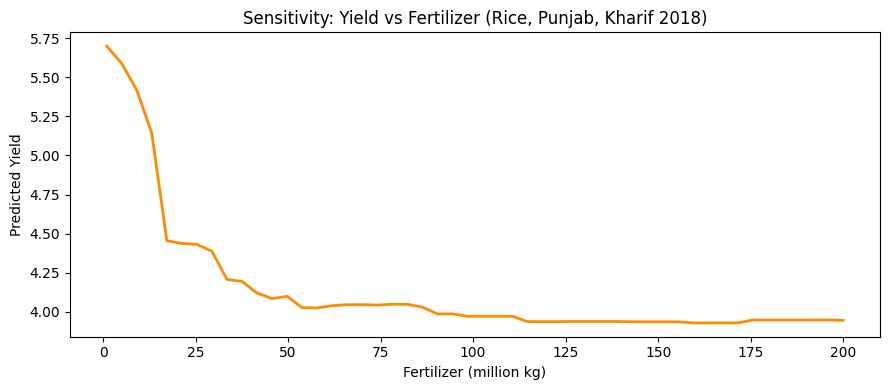

In [6]:
import matplotlib.pyplot as plt

base = example.copy()
fertilizer_range = np.linspace(1e6, 2e8, 50)

yields = []
for fert in fertilizer_range:
    base['fertilizer'] = fert
    yields.append(predictor.predict(**base))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fertilizer_range / 1e6, yields, color='darkorange', linewidth=2)
ax.set_xlabel('Fertilizer (million kg)')
ax.set_ylabel('Predicted Yield')
ax.set_title('Sensitivity: Yield vs Fertilizer (Rice, Punjab, Kharif 2018)')
plt.tight_layout()
plt.savefig('sensitivity_fertilizer.png')
plt.show()

## 7. Sensitivity Analysis — Yield vs Rainfall

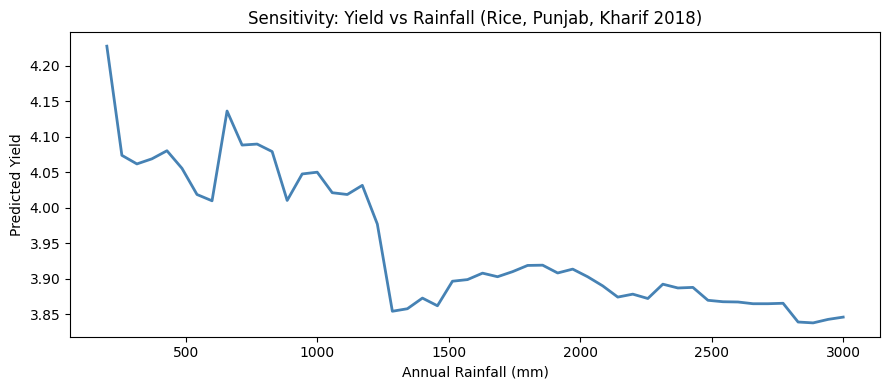

In [7]:
base = example.copy()
base['fertilizer'] = example['fertilizer']  # reset
rainfall_range = np.linspace(200, 3000, 50)

yields_rain = []
for rain in rainfall_range:
    base['annual_rainfall'] = rain
    yields_rain.append(predictor.predict(**base))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(rainfall_range, yields_rain, color='steelblue', linewidth=2)
ax.set_xlabel('Annual Rainfall (mm)')
ax.set_ylabel('Predicted Yield')
ax.set_title('Sensitivity: Yield vs Rainfall (Rice, Punjab, Kharif 2018)')
plt.tight_layout()
plt.savefig('sensitivity_rainfall.png')
plt.show()

## 8. Save Predictor

In [8]:
joblib.dump(predictor, 'models/crop_yield_predictor.pkl')
print('CropYieldPredictor saved to models/crop_yield_predictor.pkl')
print('\nTo load in any script:')
print('  import joblib')
print('  predictor = joblib.load("models/crop_yield_predictor.pkl")')
print('  yield = predictor.predict(crop, year, season, state, area, production, rainfall, fertilizer, pesticide)')

CropYieldPredictor saved to models/crop_yield_predictor.pkl

To load in any script:
  import joblib
  predictor = joblib.load("models/crop_yield_predictor.pkl")
  yield = predictor.predict(crop, year, season, state, area, production, rainfall, fertilizer, pesticide)
